#Tiem-Series model for Bitcoins historical data

##Intro to dataset

In [55]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

###Uploading df

In [84]:
df = pd.read_csv('/content/bitcoin_2010-07-17_2024-05-23.csv')
df

,Start,End,Open,High,Low,Close,Volume,Market Cap
0,2024-05-22,2024-05-23,70144.6900,70599.9700,69048.6000,69224.9900,1.161000e+11,1.375970e+12
1,2024-05-21,2024-05-22,71369.7300,71739.1400,69266.3800,70104.4000,1.403673e+11,1.391372e+12
2,2024-05-20,2024-05-21,66222.4500,71456.5500,66139.6200,71418.1700,9.769064e+10,1.332128e+12
3,2024-05-19,2024-05-20,66972.6300,67598.3100,66005.3300,66347.0500,8.441685e+10,1.317072e+12
4,2024-05-18,2024-05-19,66939.8200,67376.4100,66640.0100,66914.5800,9.377570e+10,1.318743e+12
...,...,...,...,...,...,...,...,...
5054,2010-07-21,2010-07-22,0.0792,0.0792,0.0792,0.0792,0.000000e+00,0.000000e+00
5055,2010-07-20,2010-07-21,0.0747,0.0747,0.0747,0.0747,0.000000e+00,0.000000e+00
5056,2010-07-19,2010-07-20,0.0808,0.0808,0.0808,0.0808,0.000000e+00,0.000000e+00
5057,2010-07-18,2010-07-19,0.0858,0.0858,0.0858,0.0858,0.000000e+00,0.000000e+00


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5059 entries, 0 to 5058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Start       5059 non-null   object 
 1   End         5059 non-null   object 
 2   Open        5059 non-null   float64
 3   High        5059 non-null   float64
 4   Low         5059 non-null   float64
 5   Close       5059 non-null   float64
 6   Volume      5059 non-null   float64
 7   Market Cap  5059 non-null   float64
dtypes: float64(6), object(2)
memory usage: 316.3+ KB


In [58]:
df.describe()

,Open,High,Low,Close,Volume,Market Cap
count,5059.000000,5059.000000,5059.000000,5059.000000,5.059000e+03,5.059000e+03
mean,11438.181181,11705.263065,11158.414652,11452.970652,2.080825e+10,2.151543e+11
std,16844.549351,17238.667309,16427.120330,16866.242616,3.322006e+10,3.233431e+11
min,0.050000,0.050000,0.050000,0.050000,0.000000e+00,0.000000e+00
25%,229.495500,232.678500,226.067500,229.564000,6.455739e+06,3.272665e+09
50%,2506.470000,2581.910000,2412.940000,2517.590000,1.040786e+09,4.145427e+10
75%,16723.683846,16981.321350,16480.847042,16762.880195,3.342707e+10,3.194169e+11
max,72961.030000,73628.430000,71333.360000,73087.950000,2.121515e+11,1.428493e+12


##Visualisation

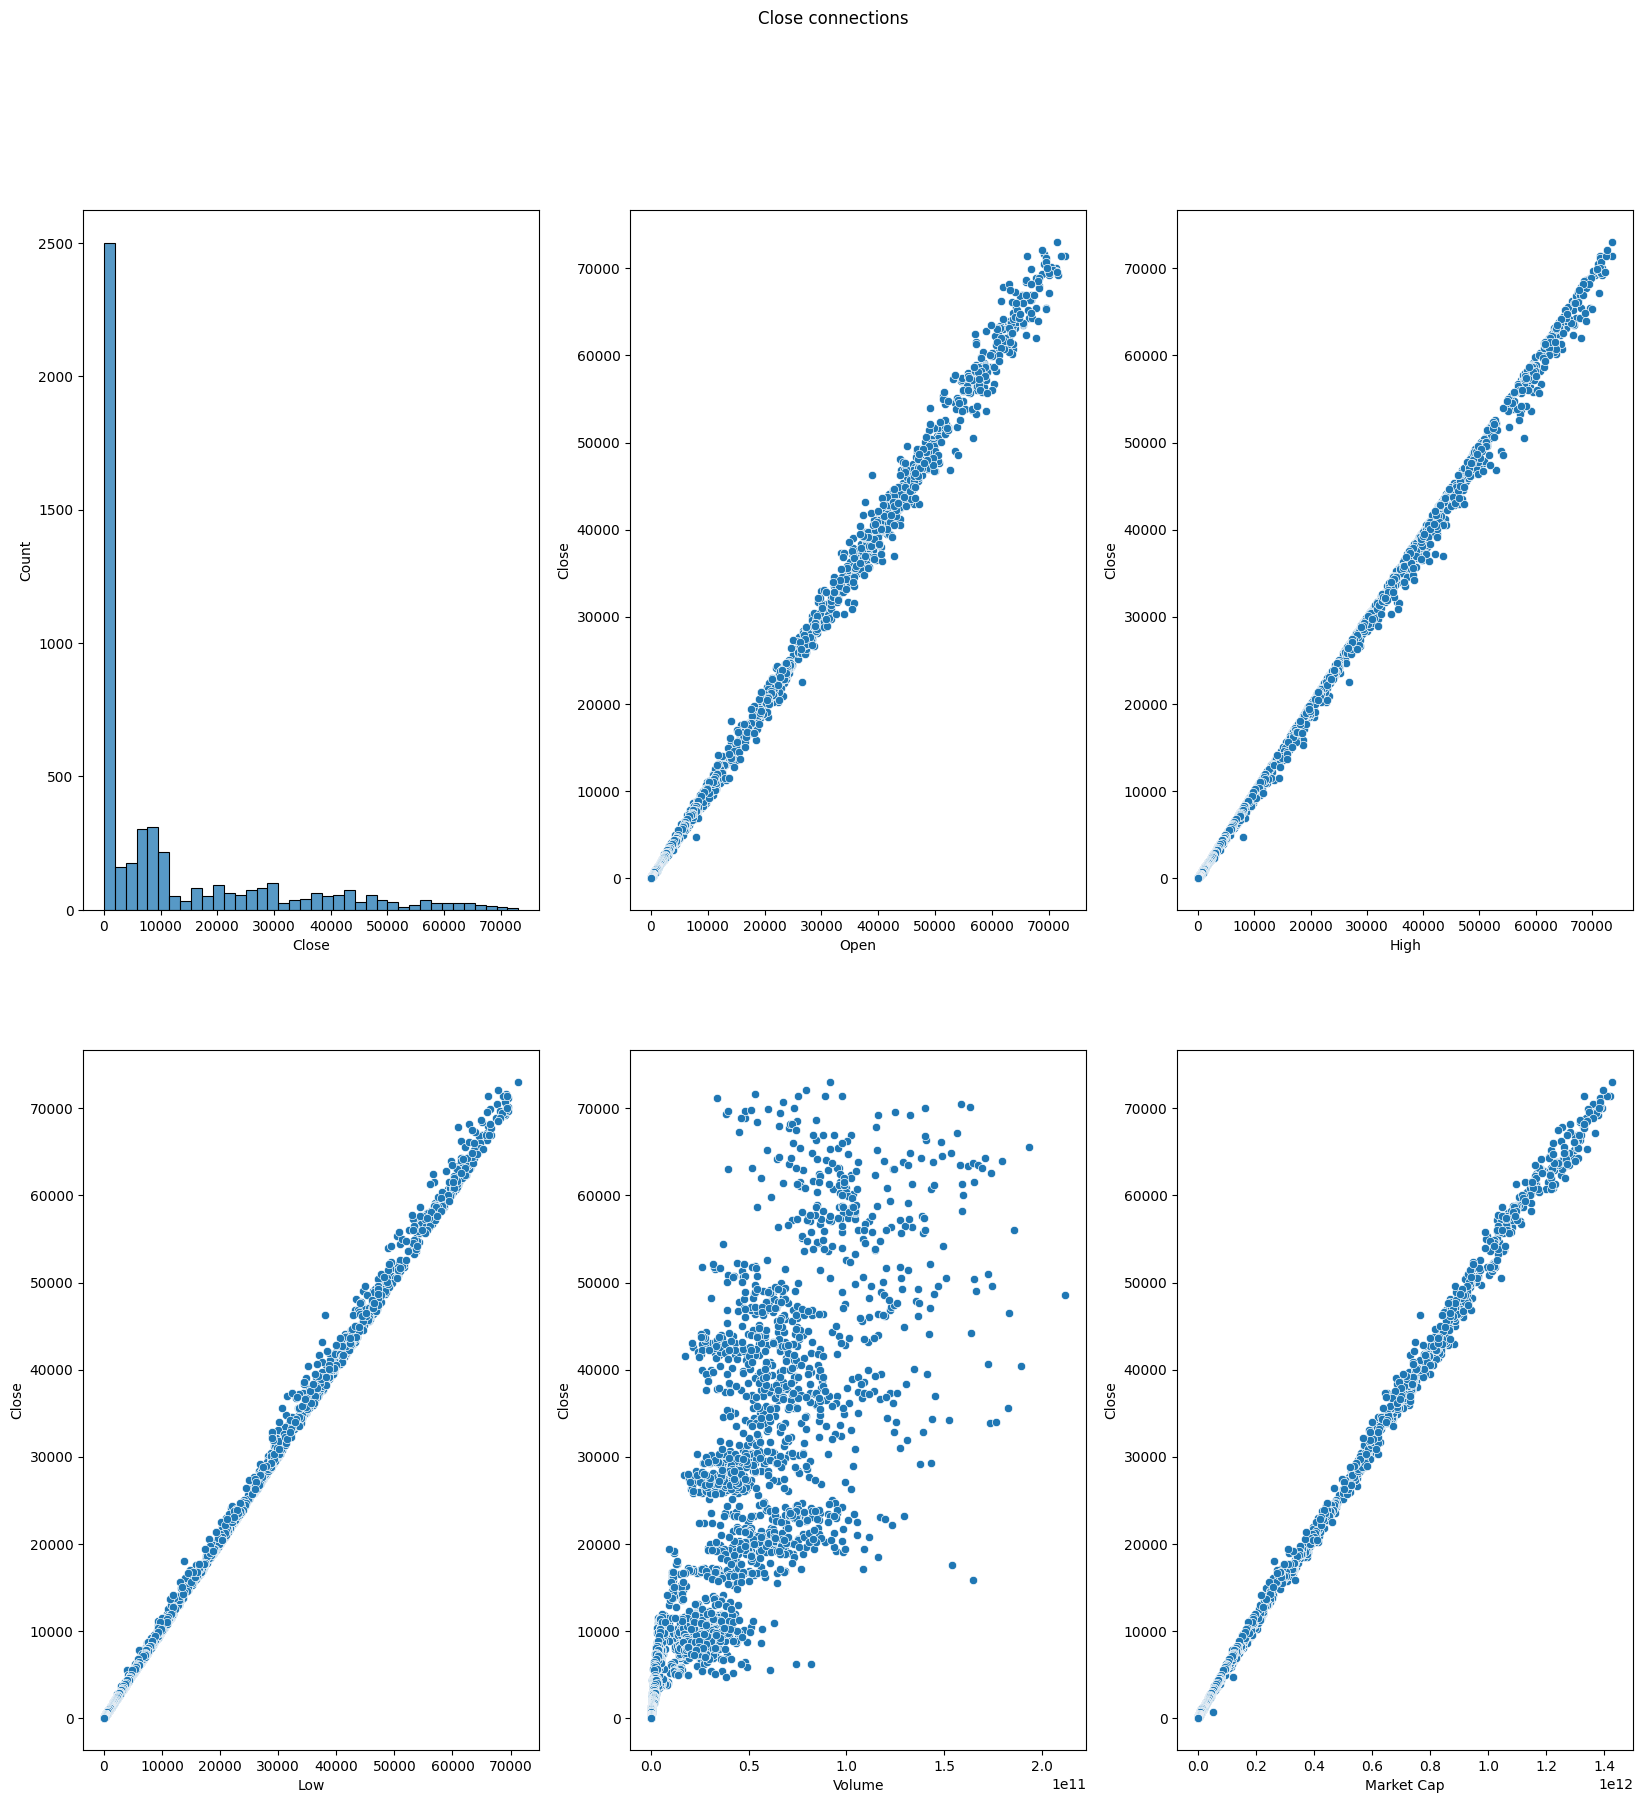

In [59]:
fig, axes = plt.subplots(2,3, figsize = (20,20))
fig.suptitle('Close connections')
sns.histplot(ax = axes[0,0], data = df, x = 'Close')
sns.scatterplot(ax = axes[0,1], data = df, x = 'Open', y = 'Close')
sns.scatterplot(ax = axes[0,2], data = df, x = 'High', y = 'Close')
sns.scatterplot(ax = axes[1,0], data = df, x = 'Low', y= 'Close')
sns.scatterplot(ax = axes[1,1], data = df, x = 'Volume', y = 'Close')
sns.scatterplot(ax = axes[1,2], data = df, x = 'Market Cap', y = 'Close')
plt.show()

In [85]:
df['Start'] = pd.to_datetime(df['Start'], format = '%Y-%m-%d')
df.drop('End', axis = 1, inplace = True)

In [86]:
import datetime as dt
df['month'] = df['Start'].dt.month
df['year'] = df['Start'].dt.year
df['day'] = df['Start'].dt.day
df['week_day'] = df['Start'].dt.weekday
df = df.sort_values(by = 'Start')
df.head(10)

,Start,Open,High,Low,Close,Volume,Market Cap,month,year,day,week_day
5058,2010-07-17,0.0500,0.0500,0.0500,0.0500,0.0,0.0,7,2010,17,5
5057,2010-07-18,0.0858,0.0858,0.0858,0.0858,0.0,0.0,7,2010,18,6
5056,2010-07-19,0.0808,0.0808,0.0808,0.0808,0.0,0.0,7,2010,19,0
5055,2010-07-20,0.0747,0.0747,0.0747,0.0747,0.0,0.0,7,2010,20,1
5054,2010-07-21,0.0792,0.0792,0.0792,0.0792,0.0,0.0,7,2010,21,2
5053,2010-07-22,0.0505,0.0505,0.0505,0.0505,0.0,0.0,7,2010,22,3
5052,2010-07-23,0.0626,0.0626,0.0626,0.0626,0.0,0.0,7,2010,23,4
5051,2010-07-24,0.0545,0.0545,0.0545,0.0545,0.0,0.0,7,2010,24,5
5050,2010-07-25,0.0505,0.0505,0.0505,0.0505,0.0,0.0,7,2010,25,6
5049,2010-07-26,0.0560,0.0560,0.0560,0.0560,0.0,0.0,7,2010,26,0


In [88]:
df = df.sort_values("Start").reset_index(drop=True)

df["target"] = df["Close"].shift(-1)

# Lag features
df["Close_lag1"] = df["Close"].shift(1)
df["Close_lag7"] = df["Close"].shift(7)
df["return_1d"] = df["Close"].pct_change()

df.dropna(inplace=True)

In [89]:
df.corrwith(df['target'])

,0
Start,0.765021
Open,0.998305
High,0.998755
Low,0.998693
Close,0.999107
Volume,0.867604
Market Cap,0.998441
month,-0.075026
year,0.766641
day,-0.008327


##Train test split

In [90]:
X = df.drop(['target', 'Start'], axis = 1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False, random_state = 42)

#Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Linear model

In [92]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'MAE: {mae}\nRMSE: {rmse}')

MAE: 778.4854973615506
RMSE: 1219.6632565346413


##Random forest

In [96]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators':[20, 50, 100, 150, 200, 300, 400]}
rf_gscv = GridSearchCV(RandomForestRegressor(), param_grid, cv=5)
rf_gscv.fit(X_train_scaled, y_train)
rf_gscv.best_params_

{'n_estimators': 400}

In [93]:
rf_model = RandomForestRegressor(n_estimators = 20)
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'MAE: {mae}\nRMSE: {rmse}')

MAE: 2251.49116852124
RMSE: 2926.7575274635847


##XGBoost

In [95]:
from xgboost import XGBRegressor

In [94]:
xgb = XGBRegressor()
xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'MAE: {mae}\nRMSE: {rmse}')

MAE: 2836.2667160696656
RMSE: 3926.416799847843


#Conclusion:
All models, including Linear, Random Forest, and XGBoost showed significant difference. By measuring Mean absolute error of their predictions, the best of them is Linear Regression model, beacuse our target ais connected to other features linearly.